# Research Paper Summarization — PEGASUS 



> **Dataset:** `ccdv/pubmed-summarization` (PubMed) dari Hugging Face  
> **Model:** `google/pegasus-xsum` (pre-trained langsung di PubMed!)

---
## 0. Install Dependencies

In [1]:
!pip install transformers datasets rouge-score sentencepiece accelerate -q


  Preparing metadata (setup.py) ... done


---
## 1. Dataset Preparation

Sesuai proposal: pakai subset **PubMed** dari Scientific Papers Dataset.  
Data dipetakan menjadi `input_text` dan `target_text`.  
Split mengikuti bawaan dataset (train/validation/test).

In [2]:
from datasets import load_dataset
import pandas as pd

print("Loading dataset PubMed dari Hugging Face...")
print("Ref: https://huggingface.co/datasets/ccdv/pubmed-summarization")

dataset = load_dataset("ccdv/pubmed-summarization")

print("\nDataset splits tersedia:")
print(dataset)
print(f"\nJumlah data:")
print(f"  Train      : {len(dataset['train']):,}")
print(f"  Validation : {len(dataset['validation']):,}")
print(f"  Test       : {len(dataset['test']):,}")


Loading dataset PubMed dari Hugging Face...
Ref: https://huggingface.co/datasets/ccdv/pubmed-summarization


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

section/train-00000-of-00005.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

section/train-00001-of-00005.parquet:   0%|          | 0.00/208M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/58.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/119924 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6658 [00:00<?, ? examples/s]


Dataset splits tersedia:
DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 119924
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6633
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6658
    })
})

Jumlah data:
  Train      : 119,924
  Validation : 6,633
  Test       : 6,658


In [3]:
# Lihat contoh satu data
sample = dataset['train'][0]
print("=== Contoh Data (Train[0]) ===")
print(f"\nKolom tersedia: {list(sample.keys())}")
print(f"\nPanjang article : {len(sample['article'].split())} kata")
print(f"Panjang abstract: {len(sample['abstract'].split())} kata")
print(f"\n--- Article (200 karakter pertama) ---")
print(sample['article'][:200])
print(f"\n--- Abstract ---")
print(sample['abstract'][:300])

=== Contoh Data (Train[0]) ===

Kolom tersedia: ['article', 'abstract']

Panjang article : 4811 kata
Panjang abstract: 248 kata

--- Article (200 karakter pertama) ---
a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5 years were mildly , moderately or severely stunted and 258 ( 240 - 274 ) million were mildly , mode

--- Abstract ---
background : the present study was carried out to assess the effects of community nutrition intervention based on advocacy approach on malnutrition status among school - aged children in shiraz , iran.materials and methods : this case - control nutritional intervention has been done between 2008 and


In [4]:
# Mapping ke input_text dan target_text sesuai proposal
def map_columns(example):
    return {
        "input_text": example["article"],
        "target_text": example["abstract"]
    }

dataset = dataset.map(map_columns, remove_columns=["article", "abstract"])

print("Kolom setelah mapping:", dataset['train'].column_names)
print("Contoh input_text (50 kata pertama):")
print(" ".join(dataset['train'][0]['input_text'].split()[:50]))


Map:   0%|          | 0/119924 [00:00<?, ? examples/s]

Map:   0%|          | 0/6633 [00:00<?, ? examples/s]

Map:   0%|          | 0/6658 [00:00<?, ? examples/s]

Kolom setelah mapping: ['input_text', 'target_text']
Contoh input_text (50 kata pertama):
a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5 years were mildly , moderately or severely stunted and 258 ( 240 - 274 ) million were mildly , moderately or severely underweight in the developing countries . in iran


In [5]:
DEBUG_MODE = True
DEBUG_SIZE = 6658
EVAL_SIZE  = 500

if DEBUG_MODE:
    train_data = dataset['train'].select(range(DEBUG_SIZE))
    val_data   = dataset['validation'].select(range(EVAL_SIZE))
    test_data  = dataset['test'].select(range(EVAL_SIZE))
    print(f"[DEBUG MODE] Subset kecil:")
else:
    train_data = dataset['train']
    val_data   = dataset['validation']
    test_data  = dataset['test']
    print(f"[FULL MODE] Seluruh dataset:")

print(f"  Train : {len(train_data):,}")
print(f"  Val   : {len(val_data):,}")
print(f"  Test  : {len(test_data):,}")


[DEBUG MODE] Subset kecil:
  Train : 6,658
  Val   : 500
  Test  : 500


In [6]:
# Simpan dataset lokal supaya tidak perlu download ulang
SAVE_PATH = "./scientific_papers_pubmed"

import os
if not os.path.exists(SAVE_PATH):
    dataset.save_to_disk(SAVE_PATH)
    print(f"Dataset disimpan ke: {SAVE_PATH}")
else:
    print(f"Dataset sudah ada di: {SAVE_PATH} — skip saving")


Saving the dataset (0/5 shards):   0%|          | 0/119924 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6633 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6658 [00:00<?, ? examples/s]

Dataset disimpan ke: ./scientific_papers_pubmed


---
## 2. Text Pre-processing

Sesuai proposal:
- **Cleaning**: gabung kalimat, hapus simbol tidak penting
- **Normalization**: rapikan spasi dan format teks
- **Tokenization**: pakai tokenizer model, atur `max_input_length` dan `max_target_length`

> ⚠️ Tidak menggunakan stemming/lemmatization/stopword removal karena Transformer butuh struktur bahasa utuh.

In [7]:
import re

def clean_text(text):
    """
    Cleaning & Normalization sesuai proposal:
    - Gabung kalimat jadi satu teks utuh
    - Hapus simbol tidak penting
    - Rapikan spasi/tab/newline
    """
    # Handle list of sentences (kalau input berupa list)
    if isinstance(text, list):
        text = " ".join(text)

    # Hapus karakter khusus yang tidak bermakna (bukan alfanumerik/punctuation ilmiah)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)

    # Normalisasi spasi, tab, newline berlebih
    text = re.sub(r'\s+', ' ', text)

    # Trim
    text = text.strip()

    return text

# Test cleaning
sample_raw = dataset['train'][0]['input_text']
sample_clean = clean_text(sample_raw)
print("Sebelum cleaning (50 karakter pertama):")
print(repr(sample_raw[:100]))
print("\nSetelah cleaning (50 karakter pertama):")
print(repr(sample_clean[:100]))

Sebelum cleaning (50 karakter pertama):
'a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5'

Setelah cleaning (50 karakter pertama):
'a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5'


In [8]:
from transformers import PegasusTokenizer

# ✅ Ganti ke versi base yang jauh lebih kecil
MODEL_NAME = "google/pegasus-xsum"
tokenizer = PegasusTokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT_LENGTH  = 512   # turunin juga dari 1024 → 512 biar hemat VRAM
MAX_TARGET_LENGTH = 128   # dari 256 → 128

print(f"Tokenizer: {MODEL_NAME}")
print(f"Max input length : {MAX_INPUT_LENGTH}")
print(f"Max target length: {MAX_TARGET_LENGTH}")


tokenizer_config.json:   0%|          | 0.00/87.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Tokenizer: google/pegasus-xsum
Max input length : 512
Max target length: 128


In [9]:
def preprocess(examples):
    """
    Full preprocessing pipeline sesuai proposal:
    Cleaning → Normalization → Tokenization
    """
    # Cleaning & Normalization
    inputs  = [clean_text(txt) for txt in examples["input_text"]]
    targets = [clean_text(txt) for txt in examples["target_text"]]

    # Tokenization input
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        padding="max_length",
        truncation=True
    )

    # Tokenization target
    labels = tokenizer(
       text_target=targets,
       max_length=MAX_TARGET_LENGTH,
       padding="max_length",
       truncation=True
    )

    # Set padding token jadi -100 agar tidak dihitung dalam loss
    labels_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels_ids
    return model_inputs

# Apply preprocessing
print("Preprocessing train data...")
tokenized_train = train_data.map(preprocess, batched=True, remove_columns=train_data.column_names)
print("Preprocessing validation data...")
tokenized_val = val_data.map(preprocess, batched=True, remove_columns=val_data.column_names)
print("Preprocessing test data...")
tokenized_test = test_data.map(preprocess, batched=True, remove_columns=test_data.column_names)

print(f"\nSelesai! Kolom tokenized: {tokenized_train.column_names}")

Preprocessing train data...


Map:   0%|          | 0/6658 [00:00<?, ? examples/s]

Preprocessing validation data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Preprocessing test data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Selesai! Kolom tokenized: ['input_ids', 'attention_mask', 'labels']


---
## 3. Model Training
 

Parameter training: learning rate, batch size, epoch dikonfigurasi di sini.

---
## 3. Model Training

In [10]:
from transformers import PegasusForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
import torch, os

os.environ["WANDB_DISABLED"] = "true"

print(f"Loading model: {MODEL_NAME}")
model = PegasusForConditionalGeneration.from_pretrained(MODEL_NAME)
model.config.use_cache = False

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"\nJumlah parameter: {model.num_parameters():,}")


Loading model: google/pegasus-xsum


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-xsum
Key                                  | Status  | 
-------------------------------------+---------+-
model.decoder.embed_positions.weight | MISSING | 
model.encoder.embed_positions.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

Device: cuda
GPU  : NVIDIA A100-SXM4-80GB
VRAM : 85.1 GB

Jumlah parameter: 766,567,424


In [11]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./pegasus-xsum-results",

    num_train_epochs=3,
    learning_rate=5e-5,

    # ✅ Turunin batch size
    per_device_train_batch_size=1,   # dari 2 → 1
    per_device_eval_batch_size=1,    # dari 2 → 1

    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    # logging_dir="./logs",
    logging_steps=10,
    save_total_limit=2,

    # ✅ Naikin gradient accumulation untuk kompensasi batch kecil
    gradient_accumulation_steps=8,   # dari 4 → 8 (efektifnya tetap batch 8)
    
    fp16=torch.cuda.is_available(),
    warmup_steps=100,
    weight_decay=0.01,
    report_to='none',  # disable wandb
)

In [12]:
# Data collator untuk seq2seq
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

# Setup Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,  # pakai processing_class (tokenizer deprecated)
    data_collator=data_collator,
)

print("Trainer siap!")
print(f"Total training steps: {len(tokenized_train) // training_args.per_device_train_batch_size * training_args.num_train_epochs}")


Trainer siap!
Total training steps: 19974


In [13]:
# ============================================================
# TRAINING
# Sesuai proposal: dilatih menggunakan data train,
# dipantau menggunakan validation set
# ============================================================
print("Mulai training BART...")
print("="*50)

train_result = trainer.train()

print("\nTraining selesai!")
print(f"Training loss akhir: {train_result.training_loss:.4f}")
print(f"Total runtime      : {train_result.metrics['train_runtime']:.1f} detik")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Mulai training BART...


Epoch,Training Loss,Validation Loss
1,20.685446,2.366967
2,20.902856,2.313745
3,19.282886,2.301520


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



Training selesai!
Training loss akhir: 21.0693
Total runtime      : 2923.7 detik


In [14]:
MODEL_SAVE_PATH = "./pegasus-xsum-finetuned"
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)
print(f"Model disimpan ke: {MODEL_SAVE_PATH}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model disimpan ke: ./pegasus-pubmed-finetuned


---
## 4. Inference — Generate Ringkasan

Sesuai proposal: setelah training, dilakukan **inferensi** untuk menghasilkan ringkasan dari data test.

In [15]:
from transformers import PegasusForConditionalGeneration, PegasusTokenizer

# Load model fine-tuned langsung (tanpa pipeline)
model_inf = PegasusForConditionalGeneration.from_pretrained("./pegasus-xsum-finetuned")
tokenizer_inf = PegasusTokenizer.from_pretrained("./pegasus-xsum-finetuned")
model_inf = model_inf.to(device)
model_inf.eval()

print("Model inferensi siap!")


Loading weights:   0%|          | 0/682 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model inferensi siap!


In [16]:
import torch

def generate_summary(text, max_length=256, min_length=50):
    inputs = tokenizer_inf(
        text,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        summary_ids = model_inf.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=max_length,
            min_length=min_length,
            no_repeat_ngram_size=3,
            num_beams=2,
            early_stopping=True
        )

    return tokenizer_inf.decode(summary_ids[0], skip_special_tokens=True)

# Test inferensi pada satu sampel
sample = test_data[0]
print("--- Generated Summary ---")
print(generate_summary(sample["input_text"]))
print("\n--- Reference Abstract ---")
print(sample["target_text"])


--- Generated Summary ---
anxiety affects of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression . however , our current understanding of anxiety and its impact on cognition in pd remains quality and lags far behind that of depression , as well as its neural basis and best treatment practices . this study aimed to investigate the relationship between anxiety and cognition in patients with p

--- Reference Abstract ---
research on the implications of anxiety in parkinson 's disease ( pd ) has been neglected despite its prevalence in nearly 50% of patients and its negative impact on quality of life . 
 previous reports have noted that neuropsychiatric symptoms impair cognitive performance in pd patients ; however , to date , no study has directly compared pd patients with and without anxiety to examine the impact of anxiety on cognitive impairments in pd . 
 this study compared cognitive performance across

In [17]:
# Generate ringkasan untuk seluruh test set
print("Generating ringkasan untuk semua data test...")

generated_summaries = []
reference_summaries = []

for i, sample in enumerate(test_data):
    gen = generate_summary(sample['input_text'])
    generated_summaries.append(gen)
    reference_summaries.append(sample['target_text'])

    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{len(test_data)}")

print(f"\nSelesai! Total ringkasan: {len(generated_summaries)}")

Generating ringkasan untuk semua data test...
  Progress: 20/500
  Progress: 40/500
  Progress: 60/500
  Progress: 80/500
  Progress: 100/500
  Progress: 120/500
  Progress: 140/500
  Progress: 160/500
  Progress: 180/500
  Progress: 200/500
  Progress: 220/500
  Progress: 240/500
  Progress: 260/500
  Progress: 280/500
  Progress: 300/500
  Progress: 320/500
  Progress: 340/500
  Progress: 360/500
  Progress: 380/500
  Progress: 400/500
  Progress: 420/500
  Progress: 440/500
  Progress: 460/500
  Progress: 480/500
  Progress: 500/500

Selesai! Total ringkasan: 500


---
## 5. Evaluation

Sesuai proposal: evaluasi menggunakan **ROUGE-1, ROUGE-2, ROUGE-L** sebagai metrik utama,
dilengkapi dengan **analisis kualitatif** beberapa sampel.

In [29]:
from rouge_score import rouge_scorer
import numpy as np

def compute_rouge(predictions, references):
    """
    Hitung ROUGE-1, ROUGE-2, ROUGE-L sesuai proposal.
    Return rata-rata F1 score.
    """
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )

    scores = {"rouge1": [], "rouge2": [], "rougeL": []}

    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores["rouge1"].append(score["rouge1"].fmeasure)
        scores["rouge2"].append(score["rouge2"].fmeasure)
        scores["rougeL"].append(score["rougeL"].fmeasure)

    return {
        "ROUGE-1": round(np.mean(scores["rouge1"]) * 100, 2),
        "ROUGE-2": round(np.mean(scores["rouge2"]) * 100, 2),
        "ROUGE-L": round(np.mean(scores["rougeL"]) * 100, 2),
    }

# Hitung ROUGE
print("Menghitung ROUGE scores...")
rouge_scores = compute_rouge(generated_summaries, reference_summaries)

print("\n" + "="*40)
print("       HASIL EVALUASI — PEGASUS")
print("="*40)
for metric, score in rouge_scores.items():
    print(f"  {metric} : {score:.2f}")
print("="*40)
print("(Skala 0-100, semakin tinggi semakin baik)")

Menghitung ROUGE scores...

       HASIL EVALUASI — PEGASUS
  ROUGE-1 : 33.54
  ROUGE-2 : 12.11
  ROUGE-L : 20.28
(Skala 0-100, semakin tinggi semakin baik)


In [19]:
# Simpan hasil ke DataFrame untuk comparative analysis nanti
results_df = pd.DataFrame([{
    "Model": "PEGASUS (google/pegasus-xsum)",
    "ROUGE-1": rouge_scores["ROUGE-1"],
    "ROUGE-2": rouge_scores["ROUGE-2"],
    "ROUGE-L": rouge_scores["ROUGE-L"],
    "Tipe": "Abstractive Baseline",
    "Dataset": "PubMed",
    "Test Samples": len(test_data)
}])

results_df.to_csv("pegasus_rouge_results.csv", index=False)
print("Hasil disimpan ke: pegasus_rouge_results.csv")
print("\n(File ini akan digunakan untuk Comparative Analysis di tahap akhir)")
results_df

Hasil disimpan ke: pegasus_rouge_results.csv

(File ini akan digunakan untuk Comparative Analysis di tahap akhir)


,Model,ROUGE-1,ROUGE-2,ROUGE-L,Tipe,Dataset,Test Samples
0,PEGASUS (google/pegasus-pubmed),33.54,12.11,20.28,Abstractive Baseline,PubMed,500


---
## 📊 Visualisasi & Metric Evaluation

Visualisasi hasil evaluasi model: ROUGE scores, distribusi per sampel, analisis panjang, dan training curves.

In [20]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np
from rouge_score import rouge_scorer as rs_mod

# ── Hitung score per sampel ──
sc = rs_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
per_sample = {'ROUGE-1': [], 'ROUGE-2': [], 'ROUGE-L': []}
for pred, ref in zip(generated_summaries, reference_summaries):
    s = sc.score(ref, pred)
    per_sample['ROUGE-1'].append(s['rouge1'].fmeasure * 100)
    per_sample['ROUGE-2'].append(s['rouge2'].fmeasure * 100)
    per_sample['ROUGE-L'].append(s['rougeL'].fmeasure * 100)

# ── Plot 1: ROUGE Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'ROUGE Evaluation — {MODEL_NAME}', fontsize=13, fontweight='bold')

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores  = [rouge_scores[m] for m in metrics]
colors  = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(metrics, scores, color=colors, width=0.5, edgecolor='white')
axes[0].set_ylim(0, max(scores) * 1.35)
axes[0].set_ylabel('F1 Score (%)')
axes[0].set_title('ROUGE Scores (Average)')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ── Plot 2: Distribusi ROUGE-1 (Histogram) ──
axes[1].hist(per_sample['ROUGE-1'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(per_sample['ROUGE-1']), color='tomato', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(per_sample["ROUGE-1"]):.2f}')
axes[1].set_xlabel('ROUGE-1 F1 Score (%)')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_title('Distribusi ROUGE-1 per Sampel')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./viz_rouge_bar_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_bar_hist.png")


Saved: viz_rouge_bar_hist.png


In [21]:
# ── Plot 3: Boxplot semua metrik ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f'Score Distribution — {MODEL_NAME}', fontsize=12, fontweight='bold')

bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452', '#55A868']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1 Score (%)')
ax.grid(True, axis='y', alpha=0.3)
for i, (m, vals) in enumerate(per_sample.items(), 1):
    med = np.median(vals)
    ax.text(i, med + 0.3, f'{med:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./viz_rouge_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_boxplot.png")


/tmp/ipykernel_1381/525352208.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),


Saved: viz_rouge_boxplot.png


In [22]:
# ── Plot 4: Panjang Input vs ROUGE-1 & Generated vs Reference ──
input_lengths = [len(sample['input_text'].split()) for sample in test_data]
gen_lengths   = [len(s.split()) for s in generated_summaries]
ref_lengths   = [len(s.split()) for s in reference_summaries]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Length Analysis — {MODEL_NAME}', fontsize=13, fontweight='bold')

# Scatter: input length vs ROUGE-1
axes[0].scatter(input_lengths, per_sample['ROUGE-1'], alpha=0.4, color='#4C72B0', s=18)
z = np.polyfit(input_lengths, per_sample['ROUGE-1'], 1)
x_line = np.linspace(min(input_lengths), max(input_lengths), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color='tomato', linewidth=2,
            linestyle='--', label='Trend')
axes[0].set_xlabel('Panjang Input (kata)')
axes[0].set_ylabel('ROUGE-1 (%)')
axes[0].set_title('Panjang Input vs ROUGE-1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar: generated vs reference length
avg_gen, avg_ref = np.mean(gen_lengths), np.mean(ref_lengths)
bars = axes[1].bar(['Generated\nSummary', 'Reference\nAbstract'],
                   [avg_gen, avg_ref],
                   color=['#4C72B0', '#55A868'], width=0.4, edgecolor='white')
axes[1].set_ylabel('Rata-rata Panjang (kata)')
axes[1].set_title('Panjang Generated vs Reference')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, [avg_gen, avg_ref]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./viz_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_length_analysis.png")


Saved: viz_length_analysis.png


In [23]:
# ── Plot 5: Training & Validation Loss Curve ──
history = trainer.state.log_history
train_steps, train_losses, eval_epochs, eval_losses = [], [], [], []

for entry in history:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_epochs.append(entry['epoch'])
        eval_losses.append(entry['eval_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Training Curves — {MODEL_NAME}', fontsize=13, fontweight='bold')

axes[0].plot(train_steps, train_losses, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss per Step')
axes[0].grid(True, alpha=0.3)

if eval_losses:
    axes[1].plot(eval_epochs, eval_losses, color='tomato', linewidth=2,
                marker='o', markersize=7, label='Val Loss')
    for ep, loss in zip(eval_epochs, eval_losses):
        axes[1].annotate(f'{loss:.4f}', (ep, loss),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=9)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss per Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No eval loss logged', ha='center', va='center',
                transform=axes[1].transAxes, fontsize=12, color='gray')

plt.tight_layout()
plt.savefig('./viz_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_training_curves.png")


Saved: viz_training_curves.png


---
## 📺 Tampilkan Visualisasi

Total visualisasi: 4

📊 Length Analysis


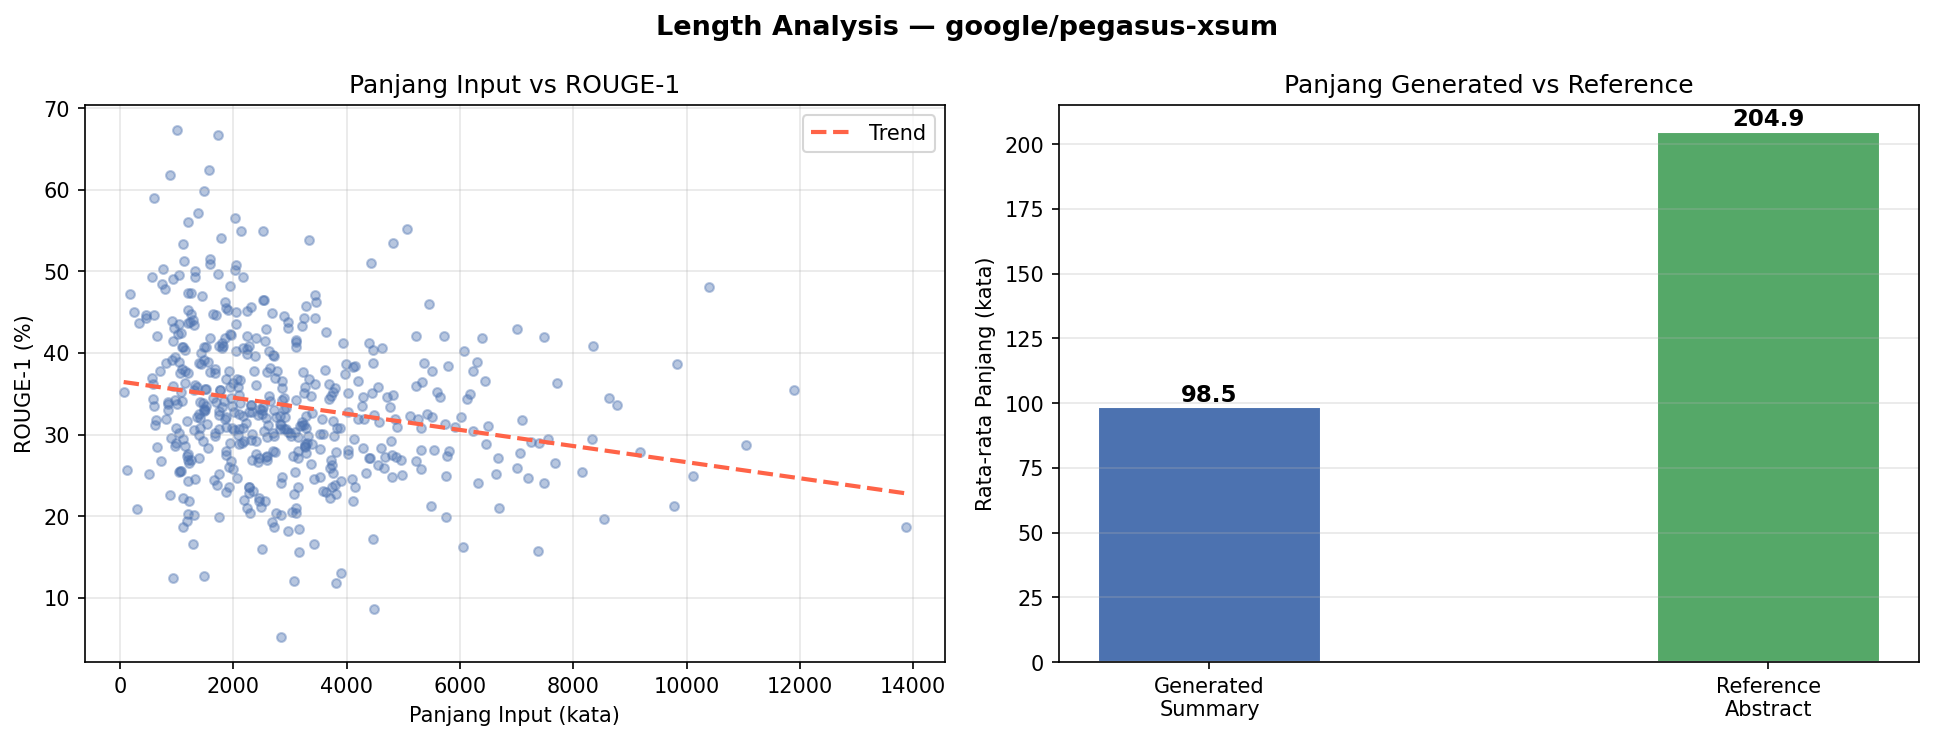


📊 Rouge Bar Hist


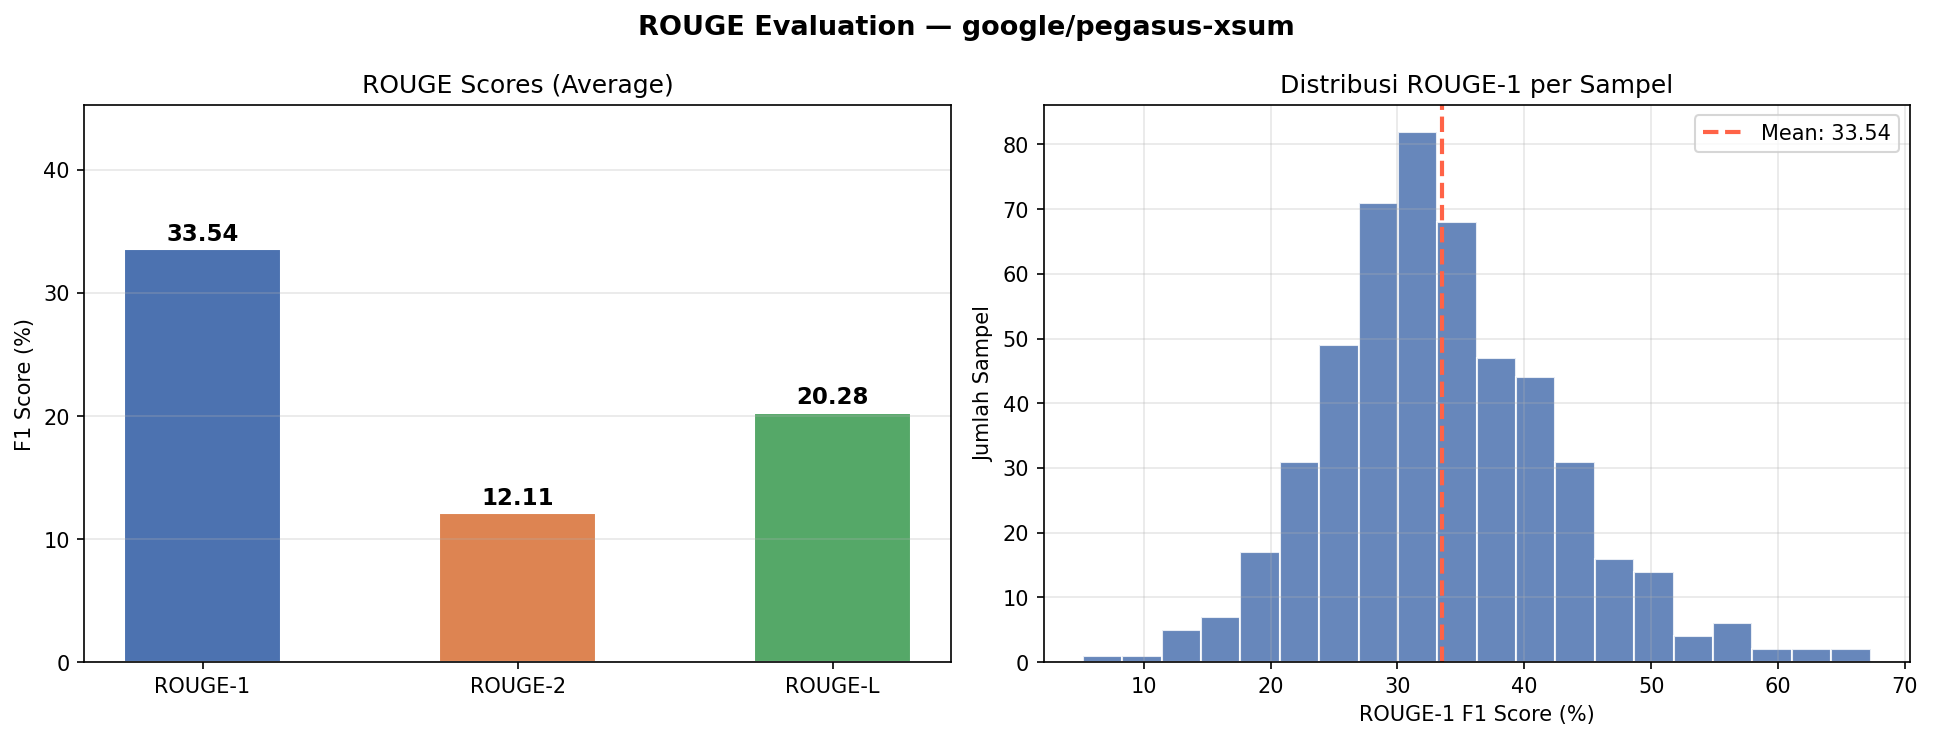


📊 Rouge Boxplot


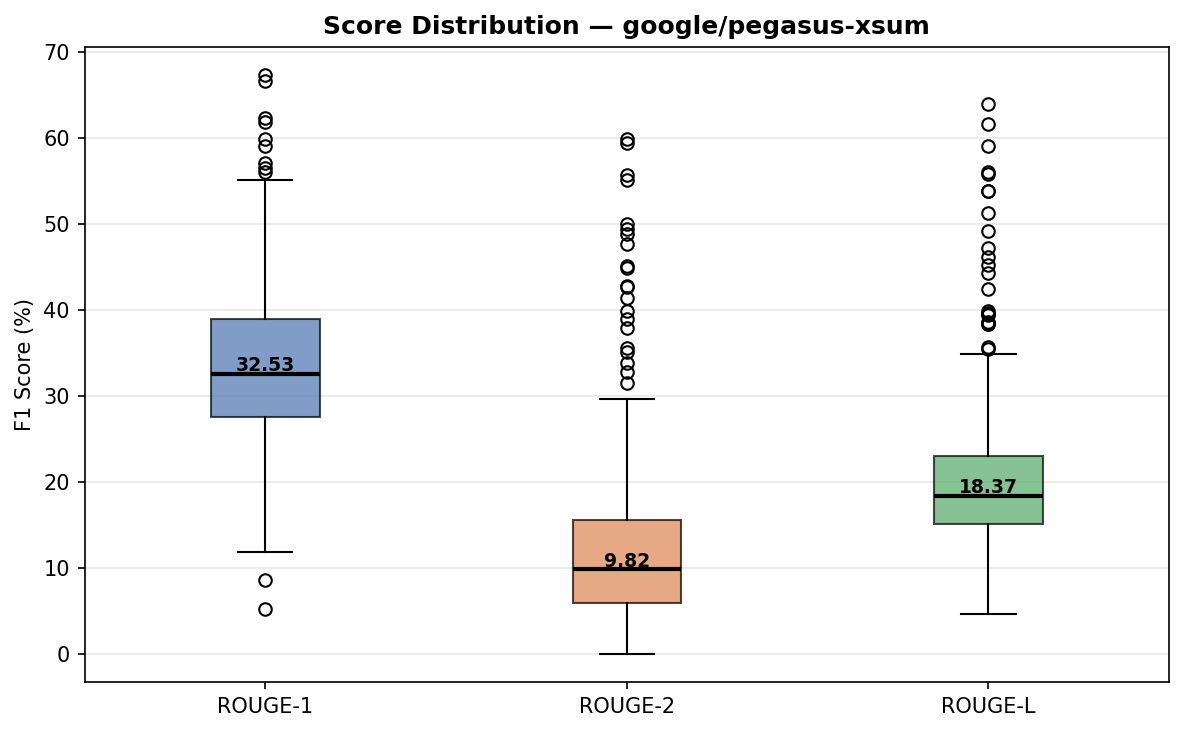


📊 Training Curves


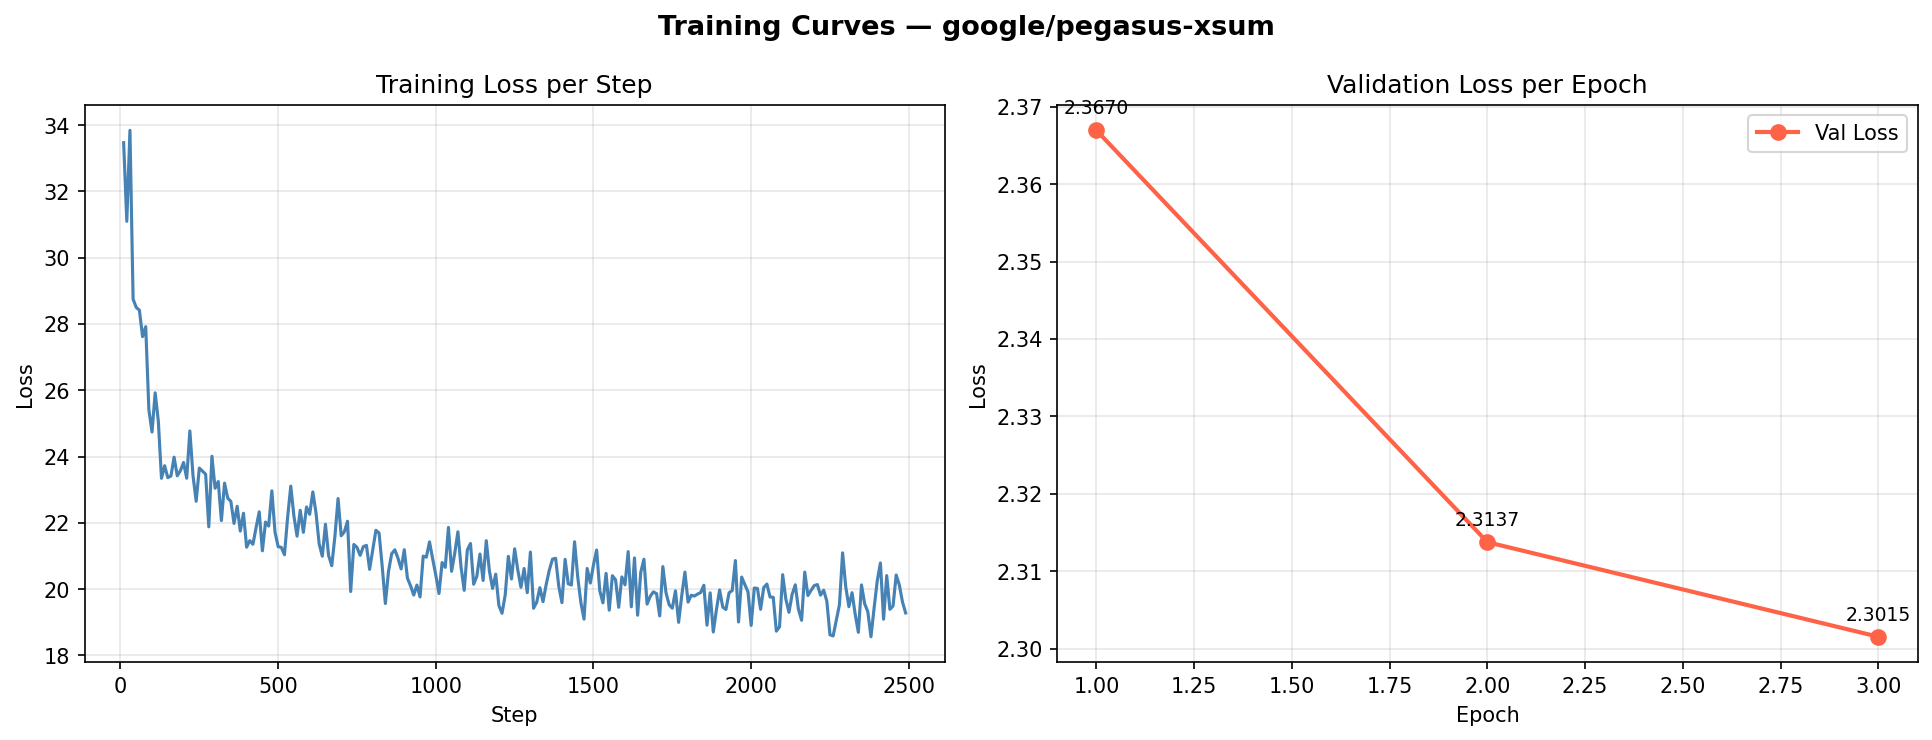

In [24]:
from IPython.display import display, Image
import glob

# ── Tampilkan semua visualisasi ──
viz_files = sorted(glob.glob('./viz_*.png'))
print(f"Total visualisasi: {len(viz_files)}")
print("=" * 50)

for f in viz_files:
    name = f.replace('./viz_', '').replace('.png', '').replace('_', ' ').title()
    print(f"\n📊 {name}")
    display(Image(filename=f, width=900))


---
## 💾 Simpan Hasil ke Google Drive

---
## 7. Groundwork — Comparative Analysis

Sesuai proposal tahap 5: hasil BART disimpan untuk dibandingkan dengan model lain (TextRank, PEGASUS, LED, LongT5).

In [27]:
import json

# Simpan semua prediksi dan referensi untuk comparative analysis
output_data = {
    "model": "PEGASUS",
    "model_name": MODEL_NAME,
    "dataset": "PubMed",
    "rouge_scores": rouge_scores,
    "num_test_samples": len(test_data),
    "max_input_length": MAX_INPUT_LENGTH,
    "max_target_length": MAX_TARGET_LENGTH,
    "predictions": generated_summaries,
    "references": reference_summaries
}

with open("pegasus_predictions.json", "w") as f:
    json.dump(output_data, f, indent=2)

print("Prediksi dan hasil disimpan ke: pegasus_predictions.json")
print("\n✅ Pipeline BART selesai! Summary:")
print(f"  Model    : {MODEL_NAME}")
print(f"  Dataset  : PubMed (ccdv/pubmed-summarization)")
print(f"  ROUGE-1  : {rouge_scores['ROUGE-1']}")
print(f"  ROUGE-2  : {rouge_scores['ROUGE-2']}")
print(f"  ROUGE-L  : {rouge_scores['ROUGE-L']}")
print("\n→ Lanjut ke notebook model berikutnya (TextRank / LongT5 / LED)!")

Prediksi dan hasil disimpan ke: pegasus_predictions.json

✅ Pipeline BART selesai! Summary:
  Model    : google/pegasus-xsum
  Dataset  : PubMed (ccdv/pubmed-summarization)
  ROUGE-1  : 33.54
  ROUGE-2  : 12.11
  ROUGE-L  : 20.28

→ Lanjut ke notebook model berikutnya (TextRank / LongT5 / LED)!


---
## 💾 Simpan Hasil ke Google Drive

In [28]:
from google.colab import drive
import shutil, os, glob

drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/PEGASUS'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Simpan visualisasi
viz_files = glob.glob('./viz_*.png')
for f in viz_files:
    shutil.copy(f, DRIVE_PATH)
    print(f'  ✅ {f} → Drive')

# Simpan hasil evaluasi
shutil.copy('pegasus_rouge_results.csv', DRIVE_PATH)
shutil.copy('pegasus_predictions.json', DRIVE_PATH)
print(f'  ✅ pegasus_rouge_results.csv → Drive')
print(f'  ✅ pegasus_predictions.json → Drive')

# Simpan model weights (opsional)
DRIVE_MODEL_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Models/PEGASUS'
os.makedirs(DRIVE_MODEL_PATH, exist_ok=True)
if not os.path.exists(f'{DRIVE_MODEL_PATH}/pegasus-xsum-finetuned'):
    print("Menyimpan model weights ke Drive... (~beberapa menit)")
    shutil.copytree('./pegasus-xsum-finetuned', f'{DRIVE_MODEL_PATH}/pegasus-xsum-finetuned')
    print(f'  ✅ Model weights → Drive')
else:
    print("Model weights sudah ada di Drive — skip")

print(f'\n✅ Semua hasil disimpan ke: {DRIVE_PATH}')


Mounted at /content/drive
  ✅ ./viz_training_curves.png → Drive
  ✅ ./viz_length_analysis.png → Drive
  ✅ ./viz_rouge_bar_hist.png → Drive
  ✅ ./viz_rouge_boxplot.png → Drive
  ✅ pegasus_rouge_results.csv → Drive
  ✅ pegasus_predictions.json → Drive
Menyimpan model weights ke Drive... (~beberapa menit)
  ✅ Model weights → Drive

✅ Semua hasil disimpan ke: /content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/PEGASUS
